## ML&Fintech HW8 Chapter 6 Q9

Name: Alvin B. Lin\
ID: 112652040\
Date: 17/11/2025\
HW #: 8

9.In this exercise, we will predict the number of applications received using the other variables in the `College` data set.

In [1]:
from ISLP import load_data

In [2]:
colledge = load_data('College')
colledge.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


(a) Split the data set into a training set and a test set.

In [3]:
# train test split
from sklearn.model_selection import train_test_split
train, test = train_test_split(colledge, test_size=0.2, random_state=42)

---

(b) Fit a linear model using least squares on the training set, and report the test error obtained.

In [10]:
Y = train.Apps
X = train.drop(['Apps', 'Private'], axis=1)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
linreg = LinearRegression()
lr = linreg.fit(X, Y)
test_x = test.drop(['Apps', 'Private'], axis=1)
test_y = test.Apps
print(f'Training R^2: {lr.score(X, Y):.4f}')
print(f'Training MSE: {mean_squared_error(Y, lr.predict(X)):.4f}')
print(f'Training MAE: {mean_absolute_error(Y, lr.predict(X)):.4f}')
print(f'Testing R^2: {lr.score(test_x, test_y):.4f}')
print(f'Testing MSE: {mean_squared_error(test_y, lr.predict(test_x)):.4f}')
print(f'Testing MAE: {mean_absolute_error(test_y, lr.predict(test_x)):.4f}')

Training R^2: 0.9335
Training MSE: 1021127.0758
Training MAE: 570.1788
Testing R^2: 0.8915
Testing MSE: 1442624.9144
Testing MAE: 713.0533


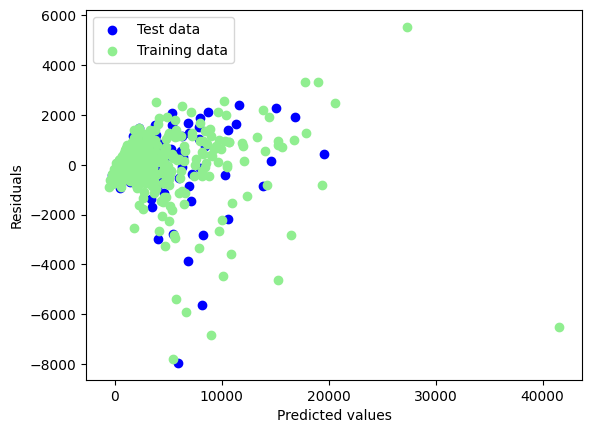

In [11]:
# residual plot
import matplotlib.pyplot as plt
plt.scatter(lr.predict(test_x), lr.predict(test_x) - test_y, c='blue', marker='o', label='Test data')
plt.scatter(lr.predict(X), lr.predict(X) - Y, c='lightgreen',
            marker='o', label='Training data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.legend(loc='upper left')

---

(c) Fit a ridge regression model on the training set, with λ chosen by cross-validation. Report the test error obtained.

In [13]:
from sklearn.linear_model import RidgeCV
import numpy as np

# choose lambda by cross-validation
alphas = np.logspace(-4, 0, 100)

ridgecv = RidgeCV(alphas=alphas, store_cv_values=True)
ridge = ridgecv.fit(X, Y)
print(f'Optimal lambda: {ridge.alpha_:.4f}')
print(f'Training R^2: {ridge.score(X, Y):.4f}')
print(f'Training MSE: {mean_squared_error(Y, ridge.predict(X)):.4f}')
print(f'Training MAE: {mean_absolute_error(Y, ridge.predict(X)):.4f}')
print(f'Testing R^2: {ridge.score(test_x, test_y):.4f}')
print(f'Testing MSE: {mean_squared_error(test_y, ridge.predict(test_x)):.4f}')
print(f'Testing MAE: {mean_absolute_error(test_y, ridge.predict(test_x)):.4f}')

Optimal lambda: 1.0000
Training R^2: 0.9335
Training MSE: 1021127.0774
Training MAE: 570.1798
Testing R^2: 0.8915
Testing MSE: 1442627.5046
Testing MAE: 713.0536


---

(d) Fit a lasso model on the training set, with λ chosen by crossvalidation. Report the test error obtained, along with the number of non-zero coefficient estimates.

In [14]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso = lassocv.fit(X, Y)
print(f'Optimal lambda: {lasso.alpha_:.4f}')
print(f'Training R^2: {lasso.score(X, Y):.4f}')
print(f'Training MSE: {mean_squared_error(Y, lasso.predict(X)):.4f}')
print(f'Training MAE: {mean_absolute_error(Y, lasso.predict(X)):.4f}')
print(f'Testing R^2: {lasso.score(test_x, test_y):.4f}')
print(f'Testing MSE: {mean_squared_error(test_y, lasso.predict(test_x)):.4f}')
print(f'Testing MAE: {mean_absolute_error(test_y, lasso.predict(test_x)):.4f}')
print(f'Number of non-zero coefficients: {np.sum(lasso.coef_ != 0)}')

Optimal lambda: 0.0001
Training R^2: 0.9335
Training MSE: 1021127.0758
Training MAE: 570.1788
Testing R^2: 0.8915
Testing MSE: 1442624.9151
Testing MAE: 713.0533
Number of non-zero coefficients: 16


---

(e) Fit a PCR model on the training set, with M chosen by crossvalidation. Report the test error obtained, along with the value of M selected by cross-validation.

In [16]:
scores = []

from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Compute the CV Score for no principal components, Linear Reg. only with intercept
scores.append(-np.mean(cross_val_score(LinearRegression(), np.ones((X.shape[0], 1)),
                                     Y, cv=5, scoring='neg_mean_squared_error')))

for i in np.arange(1, X.shape[1]+1):
    scaler = StandardScaler()
    X_ = scaler.fit_transform(X)
    
    pca = PCA(n_components=i)
    X_pcr = pca.fit_transform(X_)
    
    score = -np.mean(cross_val_score(LinearRegression(), X_pcr[:, :i],
                                    Y, cv=5, scoring='neg_mean_squared_error'))
    
    scores.append(score)

In [17]:
print(np.argmin(scores), np.min(scores))

16 1298681.1393531025


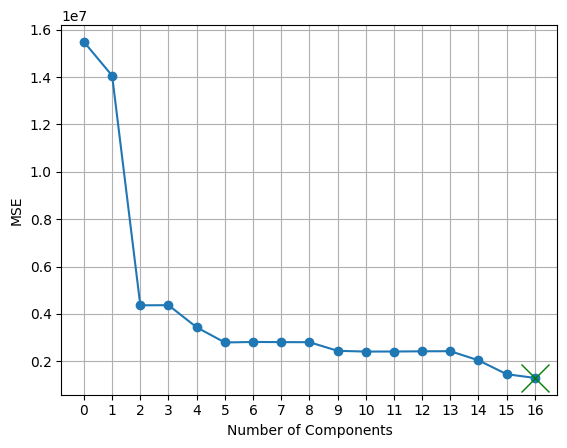

In [19]:
plt.plot(scores, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('MSE')
plt.xticks(np.arange(0, X.shape[1]+1, 1))

plt.plot(np.argmin(scores), np.min(scores), 'gx', markersize=20)
plt.grid()

$$\boxed{M = 16}$$